<a href="https://colab.research.google.com/github/aryaanjalii203/ML-Codes/blob/main/Smart_Waste_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

dataset_slug = "phenomsg/waste-classification"
download_root = "/content/kaggle_dataset"
os.makedirs(download_root, exist_ok=True)

try:
    import kagglehub
    path = kagglehub.dataset_download(dataset_slug)
    print("✅ Kagglehub download successful:", path)
except Exception as e:
    print("⚠️ kagglehub failed:", e)
    print("➡️ Trying Kaggle CLI fallback...")
    !pip install -q kaggle
    if not os.path.exists("/root/.kaggle/kaggle.json"):
        print("⚠️ Please upload kaggle.json from your Kaggle account to /root/.kaggle/")
    else:
        subprocess.run(["kaggle", "datasets", "download", "-d", dataset_slug, "-p", download_root, "--unzip"])
    path = download_root


def find_image_root(base_dir):
    for root, dirs, files in os.walk(base_dir):
        image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if len(image_files) > 5:
            return os.path.dirname(root)
    return base_dir

raw_dataset_dir = find_image_root(path)
print("✅ Dataset ready at:", raw_dataset_dir)


def list_class_folders(path):
    path = Path(path)
    folders = []
    for p in path.rglob("*"):
        if p.is_dir():
            image_files = list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) + list(p.glob("*.png"))
            if len(image_files) > 0:
                folders.append(str(p.relative_to(path)))
    return folders

classes_found = list_class_folders(raw_dataset_dir)
print("✅ Final detected classes:", classes_found)

auto_map = {}
for c in classes_found:
    name = c.lower()

    if "wet" in name or "organic" in name or "food" in name or "bio" in name:
        auto_map[c] = "wet"
    elif "dry" in name or "plastic" in name or "paper" in name or "metal" in name or "glass" in name:
        auto_map[c] = "dry"
    else:

        auto_map[c] = "dry"

print("✅ Auto-mapping (fixed):", auto_map)


OUT_ROOT = "/content/dataset_wet_dry"
train_out = os.path.join(OUT_ROOT, "train")
val_out = os.path.join(OUT_ROOT, "val")
for p in [train_out, val_out]:
    for cls in ["wet", "dry"]:
        os.makedirs(os.path.join(p, cls), exist_ok=True)

split_ratio = 0.8
for cls_folder, mapped in auto_map.items():
    src_dir = os.path.join(raw_dataset_dir, cls_folder)
    if not os.path.exists(src_dir): continue
    imgs = [f for f in os.listdir(src_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(imgs)
    n_train = int(len(imgs) * split_ratio)
    train_imgs = imgs[:n_train]
    val_imgs = imgs[n_train:]
    for fname in train_imgs:
        shutil.copy(os.path.join(src_dir, fname),
                    os.path.join(train_out, mapped, f"{cls_folder}__{fname}"))
    for fname in val_imgs:
        shutil.copy(os.path.join(src_dir, fname),
                    os.path.join(val_out, mapped, f"{cls_folder}__{fname}"))
    print(f"{cls_folder}: {len(train_imgs)} train, {len(val_imgs)} val → {mapped}")

def fill_empty_with_dummy():
    wt, dr = os.listdir(f"{train_out}/wet"), os.listdir(f"{train_out}/dry")
    if len(dr) == 0 and len(wt) > 0:
        for f in random.sample(wt, min(30, len(wt))):
            shutil.copy(f"{train_out}/wet/{f}", f"{train_out}/dry/")
    if len(os.listdir(f"{val_out}/dry")) == 0 and len(os.listdir(f"{val_out}/wet")) > 0:
        for f in random.sample(os.listdir(f"{val_out}/wet"), min(10, len(os.listdir(f"{val_out}/wet")))):
            shutil.copy(f"{val_out}/wet/{f}", f"{val_out}/dry/")
fill_empty_with_dummy()

print("✅ Dataset ready.")
for p in ["/content/dataset_wet_dry/train/wet", "/content/dataset_wet_dry/train/dry",
          "/content/dataset_wet_dry/val/wet", "/content/dataset_wet_dry/val/dry"]:
    print(p, "→", len(os.listdir(p)))


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
MODEL_PATH = "/content/swm_wet_dry_mobilenetv2.h5"

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
).flow_from_directory(train_out, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(val_out, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

num_classes = train_gen.num_classes
print("✅ Detected classes:", train_gen.class_indices)

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base.layers: layer.trainable = False
x = GlobalAveragePooling2D()(base.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base.input, outputs=out)
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)
np.save("/content/class_indices.npy", train_gen.class_indices)
print("✅ Training complete. Model saved at:", MODEL_PATH)


def load_and_preprocess(img_path, size=IMG_SIZE):
    img = Image.open(img_path).convert('RGB').resize(size)
    arr = np.array(img) / 255.0
    return arr

def predict_and_visualize(model_path, image_path):
    model = tf.keras.models.load_model(model_path)
    mapping = np.load("/content/class_indices.npy", allow_pickle=True).item()
    inv_map = {v: k for k, v in mapping.items()}
    arr = load_and_preprocess(image_path)
    pred = model.predict(np.expand_dims(arr, axis=0))[0]
    label = inv_map[np.argmax(pred)]
    conf = float(np.max(pred))
    print(f"Prediction: {label.upper()} ({conf:.2f})")

    img_cv = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    canvas = np.ones((400, 900, 3), dtype=np.uint8) * 255
    left_x, right_x = 120, 600
    bin_w, bin_h = 220, 180
    cv2.rectangle(canvas, (left_x, 160), (left_x + bin_w, 160 + bin_h), (200, 120, 80), 4)
    cv2.putText(canvas, "WET BIN", (left_x + 30, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (50, 0, 0), 2)
    cv2.rectangle(canvas, (right_x, 160), (right_x + bin_w, 160 + bin_h), (80, 160, 200), 4)
    cv2.putText(canvas, "DRY BIN", (right_x + 30, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 50), 2)
    garbage = cv2.resize(img_cv, (120, 120))
    sx, sy = 400, 20
    tx = left_x + bin_w // 2 - 60 if label == "wet" else right_x + bin_w // 2 - 60
    ty = 160 + bin_h // 2 - 60
    for i in np.linspace(0, 1, 25):
        frame = canvas.copy()
        x = int(sx + (tx - sx) * i)
        y = int(sy + (ty - sy) * i)
        frame[y:y + 120, x:x + 120] = garbage
        plt.imshow(frame)
        plt.axis('off')
        plt.title(f"Moving to {label.upper()} BIN ({conf:.2f})")
        plt.pause(0.05)
        plt.clf()
    plt.imshow(frame)
    plt.axis('off')
    plt.title(f"Placed in {label.upper()} BIN ✅")
    plt.show()

print("\n=== HOW TO USE ===")
print("Upload an image to /content/test.jpg then run:")
print("predict_and_visualize('/content/swm_wet_dry_mobilenetv2.h5', '/content/test.jpg')")


Using Colab cache for faster access to the 'waste-classification' dataset.
✅ Kagglehub download successful: /kaggle/input/waste-classification
✅ Dataset ready at: /kaggle/input/waste-classification/Organic/Organic
✅ Final detected classes: ['kitchen_waste', 'coffee_tea_bags', 'yard_trimmings', 'food_scraps', 'egg_shells']
✅ Auto-mapping (fixed): {'kitchen_waste': 'dry', 'coffee_tea_bags': 'dry', 'yard_trimmings': 'dry', 'food_scraps': 'wet', 'egg_shells': 'dry'}
kitchen_waste: 91 train, 23 val → dry
coffee_tea_bags: 117 train, 30 val → dry
yard_trimmings: 101 train, 26 val → dry
food_scraps: 117 train, 30 val → wet
egg_shells: 99 train, 25 val → dry
✅ Dataset ready.
/content/dataset_wet_dry/train/wet → 145
/content/dataset_wet_dry/train/dry → 438
/content/dataset_wet_dry/val/wet → 70
/content/dataset_wet_dry/val/dry → 114
Found 583 images belonging to 2 classes.
Found 184 images belonging to 2 classes.
✅ Detected classes: {'dry': 0, 'wet': 1}
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s

19/19 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.6680 - loss: 0.8961 - val_accuracy: 0.6739 - val_loss: 0.6156 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7769 - loss: 0.4794
Epoch 2: val_accuracy improved from 0.67391 to 0.71739, saving model to /content/swm_wet_dry_mobilenetv2.h5


19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.7791 - loss: 0.4750 - val_accuracy: 0.7174 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8392 - loss: 0.3277
Epoch 3: val_accuracy improved from 0.71739 to 0.84239, saving model to /content/swm_wet_dry_mobilenetv2.h5


19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.8389 - loss: 0.3289 - val_accuracy: 0.8424 - val_loss: 0.3529 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8483 - loss: 0.3367
Epoch 4: val_accuracy did not improve from 0.84239
19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.8479 - loss: 0.3368 - val_accuracy: 0.8370 - val_loss: 0.3348 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8240 - loss: 0.3139
Epoch 5: val_accuracy improved from 0.84239 to 0.86957, saving model to /content/swm_wet_dry_mobilenetv2.h5


19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.8251 - loss: 0.3135 - val_accuracy: 0.8696 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8516 - loss: 0.3148
Epoch 6: val_accuracy did not improve from 0.86957
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.8513 - loss: 0.3140 - val_accuracy: 0.8696 - val_loss: 0.3243 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8843 - loss: 0.2614
Epoch 7: val_accuracy did not improve from 0.86957

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.8842 - loss: 0.2622 - val_accuracy: 0.8315 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8483 - loss: 0.2956
Epoch 8: val_accuracy did not improve from 0.86957
19/19 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.8496 - loss: 0.2943 - val_accuracy: 0.8533 - val_lo

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2025-11-14 020557.png to Screenshot 2025-11-14 020557.png


In [32]:
import os
os.listdir('/content')


['.config',
 'Screenshot 2025-11-14 011957.png',
 'swm_wet_dry_mobilenetv2.h5',
 'Screenshot 2025-11-14 020557.png',
 'kaggle_dataset',
 'class_indices.npy',
 'Screenshot 2025-11-14 011355.png',
 'Screenshot 2025-11-14 011957 (2).png',
 'Screenshot 2025-11-14 020226.png',
 'drive',
 'Screenshot 2025-11-14 011957 (1).png',
 'dataset_wet_dry',
 'sample_data']

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: DRY (0.74)


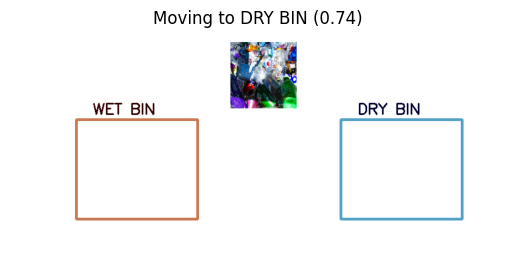

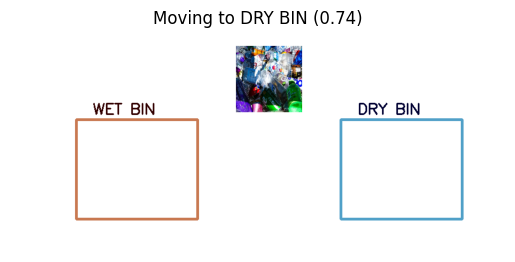

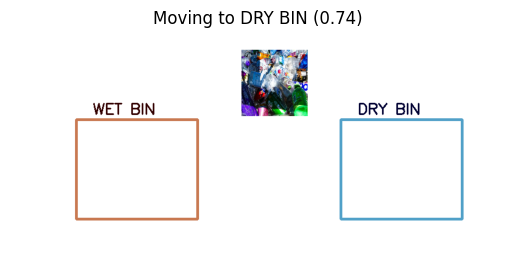

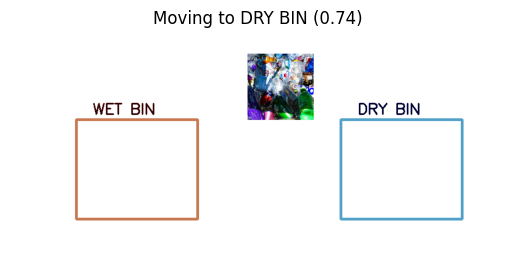

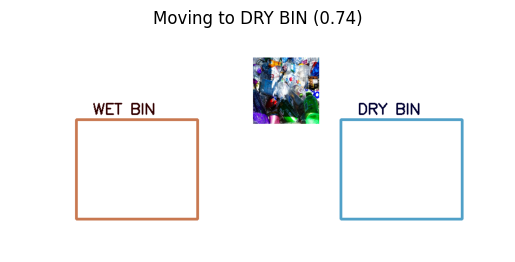

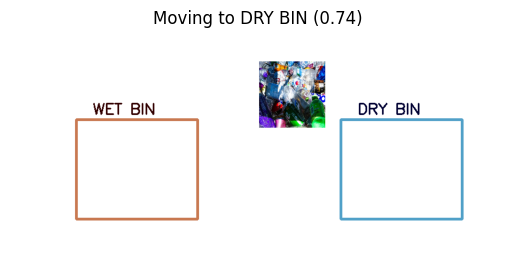

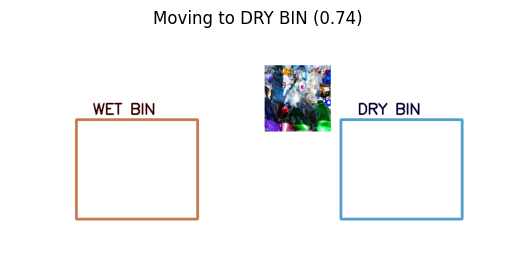

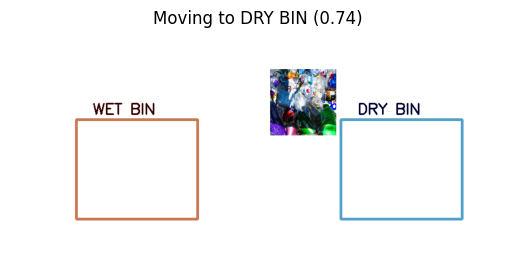

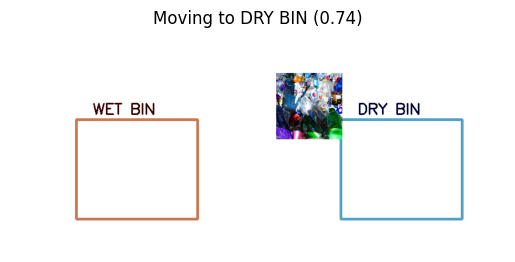

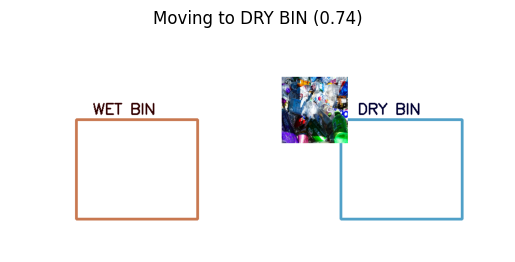

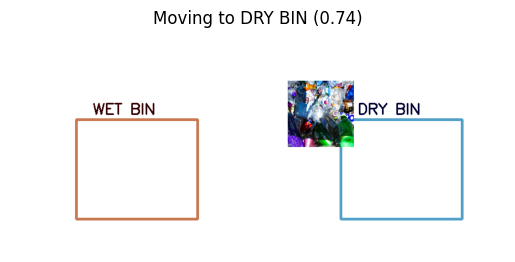

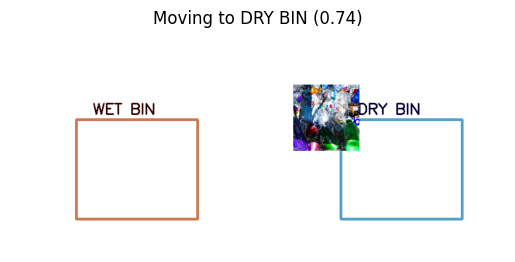

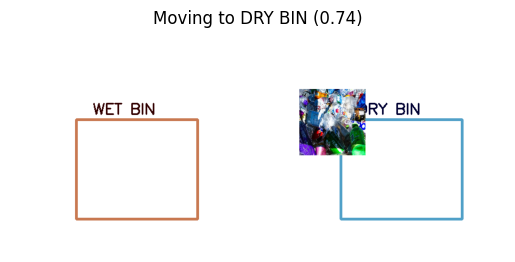

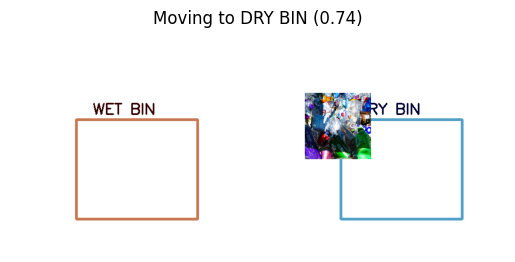

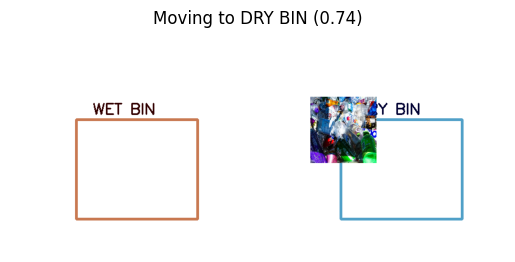

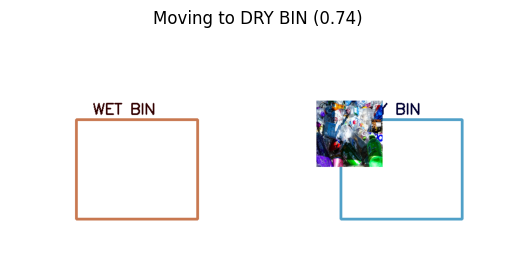

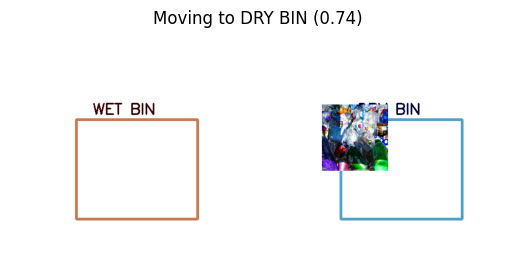

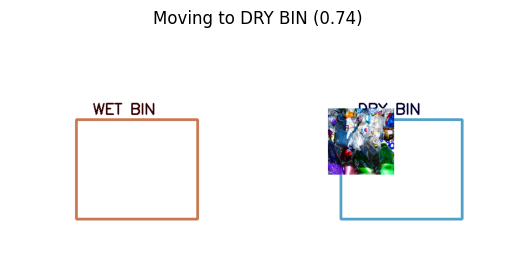

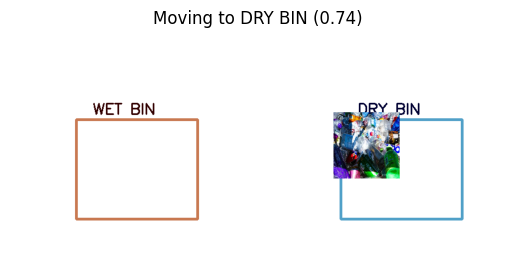

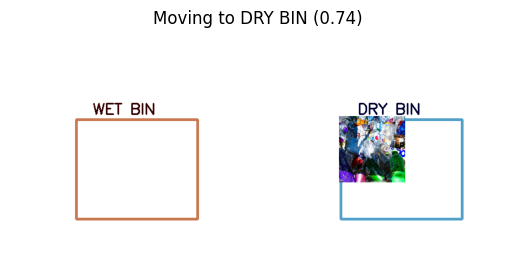

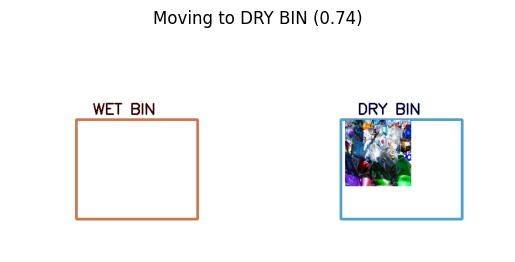

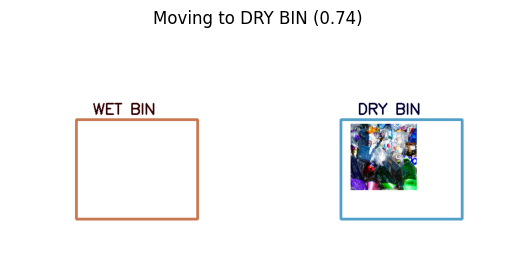

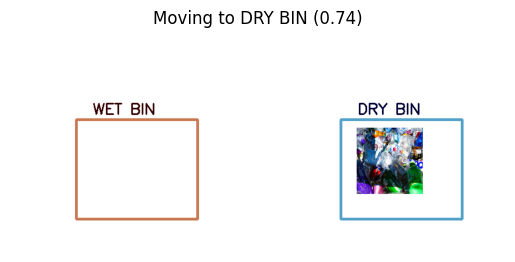

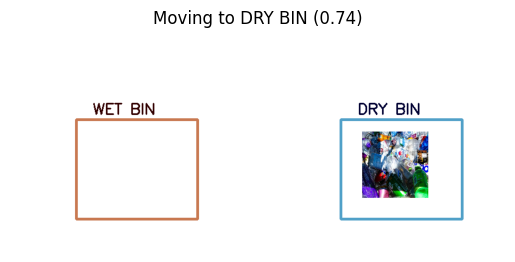

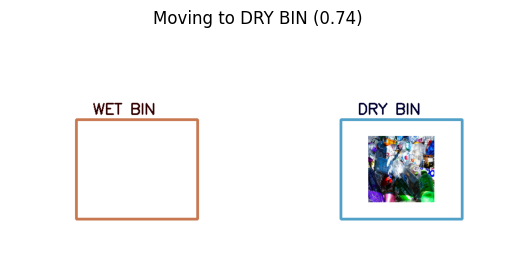

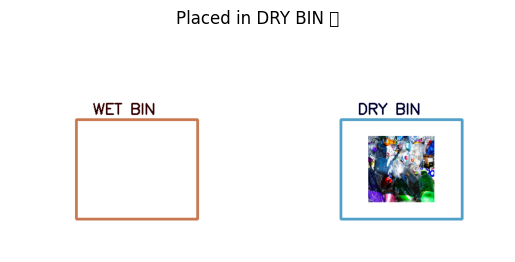

In [34]:
predict_and_visualize('/content/swm_wet_dry_mobilenetv2.h5', '/content/Screenshot 2025-11-14 020557.png')
